In [3]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# run_date = '2024-11-20_16-47-40'
run_date = '2024-11-24_20-12-49'
results_folder = os.path.join('/home/jamnic/programming/projects/poker-simulator/results', run_date)

In [3]:
import os
import json
import pandas as pd

all_results = []

for i, file in enumerate(os.listdir(results_folder)):
    file_path = os.path.join(results_folder, file)

    if i % 10 == 0:
        start = i + 1
        end = min(i + 11, len(os.listdir(results_folder)))
    
    if os.path.isfile(file_path):
        with open(file_path, 'r') as f:
            data = json.load(f)  # Load the JSON data (list of dictionaries)
            all_results.append(pd.DataFrame(data))  # Convert list of dicts to DataFrame and append to list

# Concatenate all DataFrames into a single DataFrame
all_results_df = pd.concat(all_results, axis=0, ignore_index=True)
all_results.clear()

In [4]:
all_results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000000 entries, 0 to 19999999
Data columns (total 7 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   pocket           object
 1   board            object
 2   hand_type        object
 3   main_cards       object
 4   kickers          object
 5   main_suit        object
 6   is_winning_hand  bool  
dtypes: bool(1), object(6)
memory usage: 934.6+ MB


In [5]:
# List of all hand types
hand_types = ['ROYAL_FLUSH', 'STRAIGHT_FLUSH', 'FOUR_OF_A_KIND', 'FULL_HOUSE', 'FLUSH', 'STRAIGHT', 'THREE_OF_A_KIND', 'TWO_PAIR', 'PAIR', 'HIGH_CARD']

# Loop through each hand type
for HAND_TYPE in hand_types:
    # Count the occurrences of each hand type
    hand_count = (all_results_df['hand_type'] == HAND_TYPE).sum()

    # Calculate the total number of hands (total rows)
    total_hands = len(all_results_df)

    # Calculate the percentage for the current hand type
    hand_percentage = (hand_count / total_hands) * 100

    # Print the result with the hand type and percentage
    print(f"{HAND_TYPE}: {hand_percentage:.4f}%")
    # print(all_results_df[all_results_df["hand_type"] == HAND_TYPE].head())

ROYAL_FLUSH: 0.0033%
STRAIGHT_FLUSH: 0.0279%
FOUR_OF_A_KIND: 0.1694%
FULL_HOUSE: 2.5962%
FLUSH: 3.0279%
STRAIGHT: 4.6153%
THREE_OF_A_KIND: 4.8237%
TWO_PAIR: 23.4836%
PAIR: 43.8232%
HIGH_CARD: 17.4294%


In [6]:
# Ensure that 'pocket' is represented as a string for each hand combination
all_results_df['ordered_pocket'] = all_results_df['pocket'].map(lambda card: f"{card[0]}-{card[1]}")
# Group by the 'ordered_pocket' to calculate win statistics
win_stats = all_results_df.groupby('ordered_pocket').agg(
    total_hands=('is_winning_hand', 'count'),
    total_wins=('is_winning_hand', 'sum')
)
# Calculate the win percentage
win_stats['win_percentage'] = (win_stats['total_wins'] / win_stats['total_hands']) * 100
# Sort the data by win percentage
win_stats.sort_values('win_percentage', ascending=False, inplace=True)


run_count = 10e6
player_count = 2

top_cards_count = None
# Display the results
graph = {
    'x_label': 'Starting Hand',
    'y_label': 'Win %',
    'title': f'Pre-flop Simulation Results @ {run_count:.0E} runs w/ {player_count} players' \
          f' {f'Top {top_cards_count} Cards' if top_cards_count else ''}'
}

x = win_stats.index
y = win_stats['win_percentage']
if top_cards_count:
    x = x[:top_cards_count]
    y = y[:top_cards_count]

Text(0.5, 1.0, 'Pre-flop Simulation Results @ 1E+07 runs w/ 2 players ')

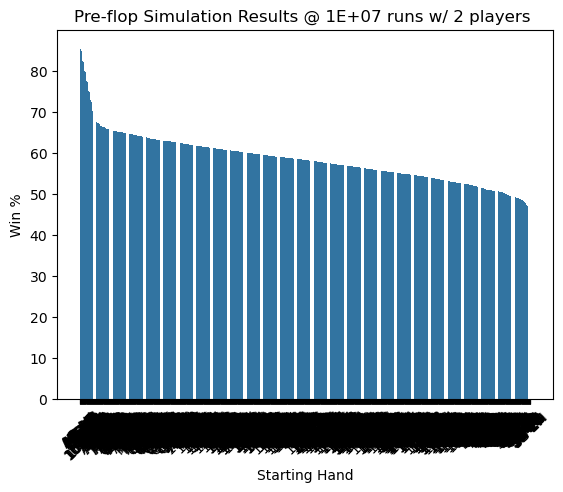

In [7]:
bar_plot = sns.barplot(x=x, y=y)
bar_plot.plot()
# plot labels
plt.xlabel(graph['x_label'])
plt.xticks(rotation=45)
plt.ylabel(graph['y_label'])
plt.title(graph['title'])

In [9]:
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'save'